# Phase 1 — Synthetic Data Augmentation

> **Note:** This notebook represents the original approach when only 15 real home sales were available.
> SDV was used to generate 1,000 synthetic rows to make model training feasible.
>
> The project has since grown: `scripts/collect_data.py` expanded the real dataset to **3,173 sales**.
> For the current model trained on real data, see **[model_training.ipynb](model_training.ipynb)**.

---

Uses SDV to generate synthetic house sales data from the real 15-row dataset, then trains a Random Forest model using the existing project pipeline.

In [1]:
import math
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, '..')

## 1. Load Real Data

In [2]:
df_real = pd.read_csv("../data/house_sales.csv")
print(f"Real dataset: {df_real.shape[0]} rows, {df_real.shape[1]} columns")
df_real.head()

Real dataset: 15 rows, 11 columns


,address,city,date_of_sale,sold_price,bedrooms,sq_ft,type,build_age,school_score,unemployment,interest_rate
0,460 N Civic Dr #409,Walnut Creek,1/28/22,347000,1,704,Condo,53,23,4.0,3.55
1,1875 Granada Dr,Concord,5/12/21,780000,3,1732,Single-family,76,11,5.8,3.00
2,1628 Armstrong Ct,Concord,12/22/23,715351,3,1445,Townhome,48,13,3.8,6.67
3,5502 Sun Cloud Ct,Concord,3/20/24,1300000,4,2331,Single-family,40,17,3.9,6.74
4,2720 Atlantic St,Concord,3/10/23,515000,2,742,Single-family,83,9,3.5,6.73


## 2. Set Up SDV Metadata

SDV needs to know the column types before fitting. We auto-detect and then manually correct `address` (unique ID, not learnable) and `date_of_sale` (datetime).

In [3]:
from sdv.metadata import SingleTableMetadata

metadata = SingleTableMetadata()
metadata.detect_from_dataframe(df_real)

# address is a unique property identifier â€” mark as id so SDV doesn't try to model it
metadata.update_column(column_name='address', sdtype='id')

# correct the date format
metadata.update_column(column_name='date_of_sale', sdtype='datetime', datetime_format='%m/%d/%y')

metadata.validate()
print("Metadata validated successfully.")
metadata.to_dict()

Metadata validated successfully.


{'primary_key': 'address',
 'METADATA_SPEC_VERSION': 'SINGLE_TABLE_V1',
 'columns': {'address': {'sdtype': 'id'},
  'city': {'pii': True, 'sdtype': 'city'},
  'date_of_sale': {'sdtype': 'datetime', 'datetime_format': '%m/%d/%y'},
  'sold_price': {'sdtype': 'numerical'},
  'bedrooms': {'sdtype': 'numerical'},
  'sq_ft': {'sdtype': 'numerical'},
  'type': {'sdtype': 'categorical'},
  'build_age': {'sdtype': 'numerical'},
  'school_score': {'sdtype': 'numerical'},
  'unemployment': {'sdtype': 'numerical'},
  'interest_rate': {'sdtype': 'numerical'}}}

## 3. Fit GaussianCopulaSynthesizer and Generate Synthetic Data

`GaussianCopulaSynthesizer` models the joint distribution of all columns using a Gaussian copula, preserving correlations between features (e.g. sq_ft vs sold_price).

In [4]:
from sdv.single_table import GaussianCopulaSynthesizer

synthesizer = GaussianCopulaSynthesizer(metadata)
synthesizer.fit(df_real)

df_synthetic = synthesizer.sample(num_rows=1000)
print(f"Synthetic dataset: {df_synthetic.shape[0]} rows")
df_synthetic.head()

C:\root\ElijahA\.venv\Lib\site-packages\sdv\single_table\base.py:183: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
C:\root\ElijahA\.venv\Lib\site-packages\sdv\single_table\base.py:139: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


Synthetic dataset: 1000 rows


,address,city,date_of_sale,sold_price,bedrooms,sq_ft,type,build_age,school_score,unemployment,interest_rate
0,sdv-id-swEwwK,Michaelport,08/28/23,680681,4,1221,Single-family,60,19,3.4,6.88
1,sdv-id-SECUxr,Ralphchester,10/10/21,615144,4,1055,Single-family,83,8,4.9,2.98
2,sdv-id-ZUiHJi,East Madison,11/13/21,1011746,4,1084,Single-family,34,11,6.3,3.14
3,sdv-id-LIEPgM,Amyborough,01/09/22,636952,4,776,Condo,34,23,5.0,5.99
4,sdv-id-alqnIw,Joshuaville,12/16/20,606951,4,1545,Condo,24,18,4.3,6.62


## 4. Compare Real vs Synthetic Distributions

Quick sanity check â€” synthetic data should roughly match the real data's statistics.

In [5]:
num_cols = ['sold_price', 'sq_ft', 'bedrooms', 'build_age', 'school_score', 'unemployment', 'interest_rate']

comparison = pd.DataFrame({
    'real_mean':      df_real[num_cols].mean(),
    'synthetic_mean': df_synthetic[num_cols].mean(),
    'real_std':       df_real[num_cols].std(),
    'synthetic_std':  df_synthetic[num_cols].std(),
}).round(2)

comparison

,real_mean,synthetic_mean,real_std,synthetic_std
sold_price,713456.73,713236.14,329464.90,303938.09
sq_ft,1484.13,1444.92,833.68,808.72
bedrooms,2.73,3.56,1.03,0.64
build_age,59.27,53.25,16.82,21.80
school_score,13.60,15.78,5.63,5.39
unemployment,4.49,4.34,1.32,1.23
interest_rate,4.99,5.06,1.73,1.69


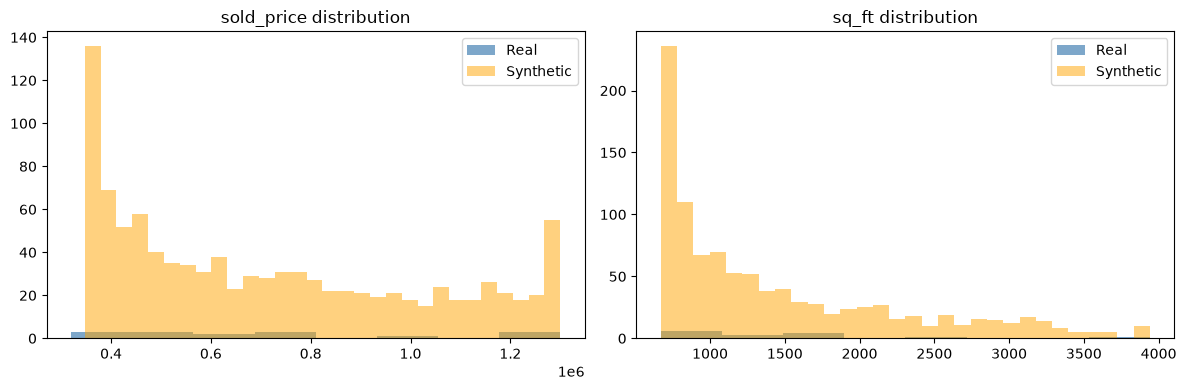

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_real['sold_price'], bins=8, alpha=0.7, label='Real', color='steelblue')
axes[0].hist(df_synthetic['sold_price'], bins=30, alpha=0.5, label='Synthetic', color='orange')
axes[0].set_title('sold_price distribution')
axes[0].legend()

axes[1].hist(df_real['sq_ft'], bins=8, alpha=0.7, label='Real', color='steelblue')
axes[1].hist(df_synthetic['sq_ft'], bins=30, alpha=0.5, label='Synthetic', color='orange')
axes[1].set_title('sq_ft distribution')
axes[1].legend()

plt.tight_layout()
plt.show()

## 5. Build the Model Pipeline

Reuses `TypeDummyCreator` from `src/ElijahA/preprocessing.py`, now updated to handle multiple categorical columns (`type` and `city`). `StandardScaler` is omitted â€” Random Forest splits on thresholds and is invariant to feature scaling.

In [7]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

from src.ElijahA.preprocessing import TypeDummyCreator

In [8]:
FEATURES = ['type', 'city', 'bedrooms', 'sq_ft', 'build_age', 'school_score', 'unemployment', 'interest_rate']
LABEL = 'sold_price'

X = df_synthetic[FEATURES].copy()
y = df_synthetic[LABEL].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows")

Train: 800 rows | Test: 200 rows


In [9]:
pipeline = Pipeline([
    ('type_dummy', TypeDummyCreator(columns=['type', 'city'])),
    ('model',      RandomForestRegressor(n_estimators=100, random_state=42)),
])

pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('type_dummy', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,columns,"['type', 'city']"
Name,Type,Value
categories_,dict,"{'city': ['Al...re', 'Al...gh', 'Al...rt', 'Al...re', ...], 'type': ['Condo', 'Si...ly', 'To...me']}"
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None


## 6. Evaluate

In [10]:
predictions = pipeline.predict(X_test)
rmse = math.sqrt(mean_squared_error(y_test, predictions))
print(f"RMSE: ${rmse:,.0f}")

RMSE: $197,427


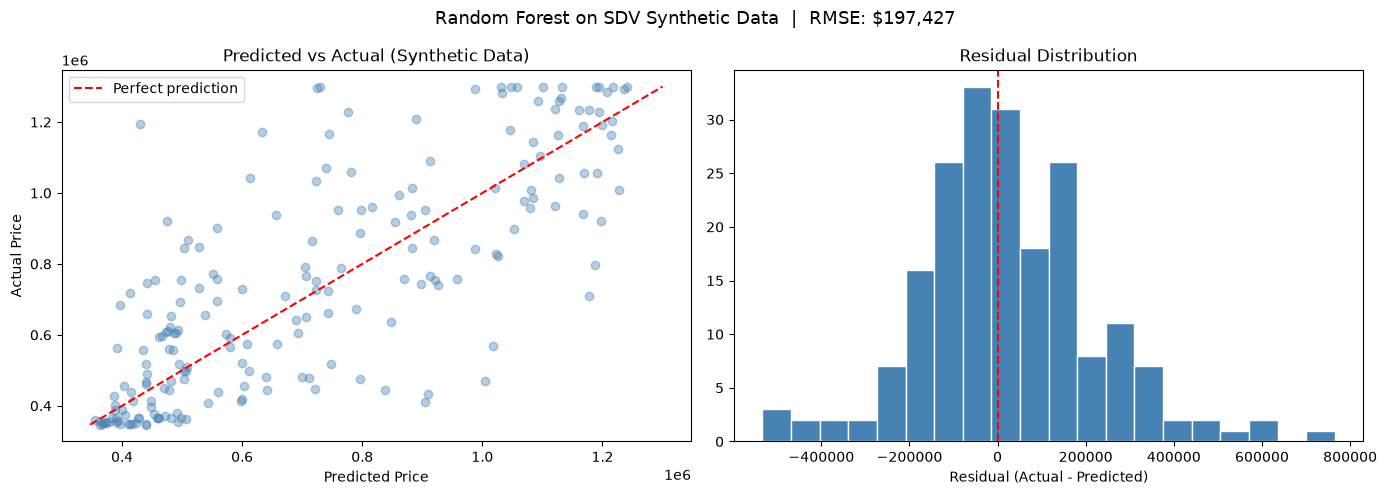

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# predicted vs actual scatter
axes[0].scatter(predictions, y_test, alpha=0.4, color='steelblue')
lims = [min(y_test.min(), predictions.min()), max(y_test.max(), predictions.max())]
axes[0].plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
axes[0].set_xlabel('Predicted Price')
axes[0].set_ylabel('Actual Price')
axes[0].set_title('Predicted vs Actual (Synthetic Data)')
axes[0].legend()

# residuals
residuals = y_test.values - predictions
axes[1].hist(residuals, bins=20, color='steelblue', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_xlabel('Residual (Actual - Predicted)')
axes[1].set_title('Residual Distribution')

plt.suptitle(f'Random Forest on SDV Synthetic Data  |  RMSE: ${rmse:,.0f}', fontsize=13)
plt.tight_layout()
plt.show()

## 7. Feature Importance

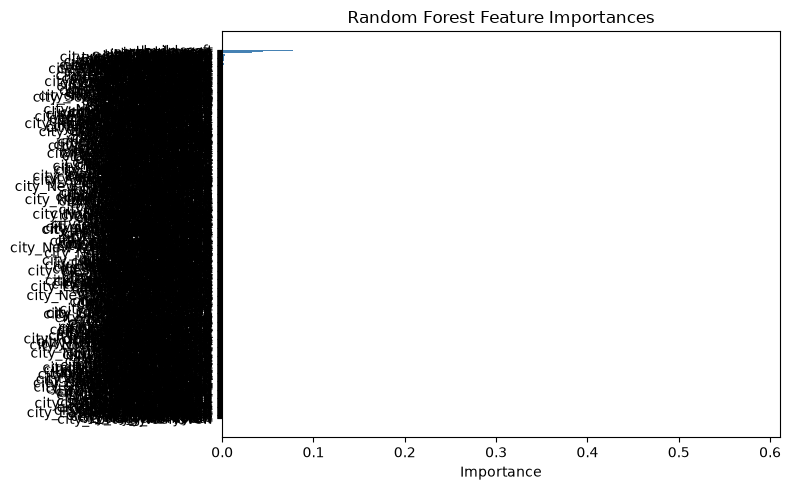

In [12]:
rf_model = pipeline.named_steps['model']

# get feature names after TypeDummyCreator expands 'type' into dummies
X_transformed = pipeline.named_steps['type_dummy'].transform(X_train)
feature_names = X_transformed.columns.tolist()

importance_df = pd.DataFrame({
    'feature':   feature_names,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(importance_df['feature'], importance_df['importance'], color='steelblue')
plt.xlabel('Importance')
plt.title('Random Forest Feature Importances')
plt.tight_layout()
plt.show()

## 8. Validate on Real Data

The model was trained on synthetic data â€” here we check how it performs on all 15 real rows, then run Leave-One-Out CV (LOOCV) on the real data to get a grounded error estimate uncontaminated by the synthesizer.

In [13]:
X_real = df_real[FEATURES].copy()
y_real = df_real[LABEL].copy()

real_preds = pipeline.predict(X_real)
real_rmse = math.sqrt(mean_squared_error(y_real, real_preds))

result_df = pd.DataFrame({
    'address':   df_real['address'].values,
    'actual':    y_real.values.astype(int),
    'predicted': real_preds.astype(int),
    'error':     (real_preds - y_real.values).astype(int),
})
print(f"Synthetic-trained model on real data  â€”  RMSE: ${real_rmse:,.0f}")
result_df

Synthetic-trained model on real data  â€”  RMSE: $151,077


,address,actual,predicted,error
0,460 N Civic Dr #409,347000,366273,19273
1,1875 Granada Dr,780000,726741,-53258
2,1628 Armstrong Ct,715351,559731,-155619
3,5502 Sun Cloud Ct,1300000,949826,-350173
4,2720 Atlantic St,515000,455505,-59494
5,2200 Laguna Cir Unit C,320000,394019,74019
6,606 Amador Ct,989000,1051569,62569
7,3556 Hillsborough,610000,781891,171891
8,1038 Pleasant Valley Dr,1225000,917262,-307737
9,2030 Date St,630000,678610,48610


In [14]:
from sklearn.model_selection import LeaveOneOut, cross_val_score

loo_pipeline = Pipeline([
    ('type_dummy', TypeDummyCreator(columns=['type', 'city'])),
    ('model',      RandomForestRegressor(n_estimators=100, random_state=42)),
])

loo_scores = cross_val_score(
    loo_pipeline, X_real, y_real,
    cv=LeaveOneOut(),
    scoring='neg_root_mean_squared_error',
)
loo_rmse = -loo_scores.mean()
print(f"LOOCV on real data               â€”  RMSE: ${loo_rmse:,.0f}")
print(f"Synthetic test set               â€”  RMSE: ${rmse:,.0f}")
print(f"Synthetic-trained â†’ real data    â€”  RMSE: ${real_rmse:,.0f}")

LOOCV on real data               â€”  RMSE: $139,915
Synthetic test set               â€”  RMSE: $197,427
Synthetic-trained â†’ real data    â€”  RMSE: $151,077
